Import Libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


Load Dataset

In [2]:
# Load training datasets
df = pd.read_csv('train.csv')    
# Preview the data
print("Training Data:")
print(df.head())

Training Data:
       ID  Gender Ever_Married  Age Graduated     Profession  Work_Experience  \
0  462809    Male           No   22        No     Healthcare              1.0   
1  462643  Female          Yes   38       Yes       Engineer              NaN   
2  466315  Female          Yes   67       Yes       Engineer              1.0   
3  461735    Male          Yes   67       Yes         Lawyer              0.0   
4  462669  Female          Yes   40       Yes  Entertainment              NaN   

  Spending_Score  Family_Size  Var_1 Segmentation  
0            Low          4.0  Cat_4            D  
1        Average          3.0  Cat_4            A  
2            Low          1.0  Cat_6            B  
3           High          2.0  Cat_6            B  
4           High          6.0  Cat_6            A  


Exploratory Data Analysis

In [3]:
# EDA (Understanding Data)
print("Shape of DataFrame:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")



Shape of DataFrame:
Rows: 8068, Columns: 11



In [4]:
print("First 5 Rows:")
print(df.head(), "\n")

First 5 Rows:
       ID  Gender Ever_Married  Age Graduated     Profession  Work_Experience  \
0  462809    Male           No   22        No     Healthcare              1.0   
1  462643  Female          Yes   38       Yes       Engineer              NaN   
2  466315  Female          Yes   67       Yes       Engineer              1.0   
3  461735    Male          Yes   67       Yes         Lawyer              0.0   
4  462669  Female          Yes   40       Yes  Entertainment              NaN   

  Spending_Score  Family_Size  Var_1 Segmentation  
0            Low          4.0  Cat_4            D  
1        Average          3.0  Cat_4            A  
2            Low          1.0  Cat_6            B  
3           High          2.0  Cat_6            B  
4           High          6.0  Cat_6            A   



In [5]:
   
print("Column Data Types:")
print(df.dtypes, "\n")
    


Column Data Types:
ID                   int64
Gender                 str
Ever_Married           str
Age                  int64
Graduated              str
Profession             str
Work_Experience    float64
Spending_Score         str
Family_Size        float64
Var_1                  str
Segmentation           str
dtype: object 



In [6]:
print("Missing Values Per Column:")
print(df.isnull().sum(), "\n")

Missing Values Per Column:
ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64 



In [7]:
print("Summary Statistics (Numeric Columns, rounded to 1 decimal place):")
print(df.describe().round(1), "\n")


Summary Statistics (Numeric Columns, rounded to 1 decimal place):
             ID     Age  Work_Experience  Family_Size
count    8068.0  8068.0           7239.0       7733.0
mean   463479.2    43.5              2.6          2.9
std      2595.4    16.7              3.4          1.5
min    458982.0    18.0              0.0          1.0
25%    461240.8    30.0              0.0          2.0
50%    463472.5    40.0              1.0          3.0
75%    465744.2    53.0              4.0          4.0
max    467974.0    89.0             14.0          9.0 



In [8]:
    
print("Number of Unique Values Per Column:")
print(df.nunique(), "\n")


Number of Unique Values Per Column:
ID                 8068
Gender                2
Ever_Married          2
Age                  67
Graduated             2
Profession            9
Work_Experience      15
Spending_Score        3
Family_Size           9
Var_1                 7
Segmentation          4
dtype: int64 



In [9]:

print("DataFrame Info:")
print(df.info(), "\n")

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   str    
 2   Ever_Married     7928 non-null   str    
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   str    
 5   Profession       7944 non-null   str    
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   str    
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   str    
 10  Segmentation     8068 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 693.5 KB
None 



In [10]:
warnings.filterwarnings('ignore')

Data Visualization

In [11]:
# Set style
sns.set(style="whitegrid")

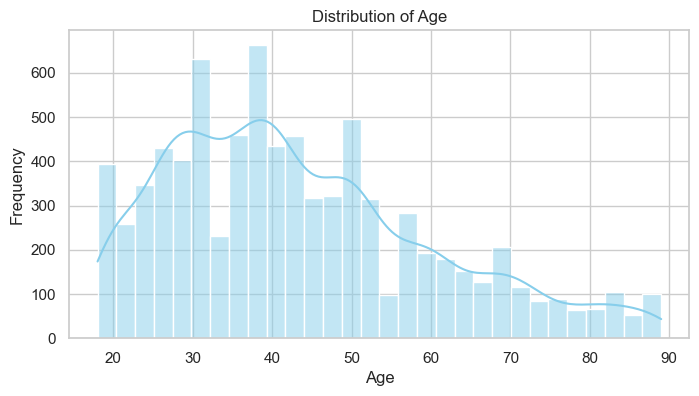

In [12]:
# 1. Age distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

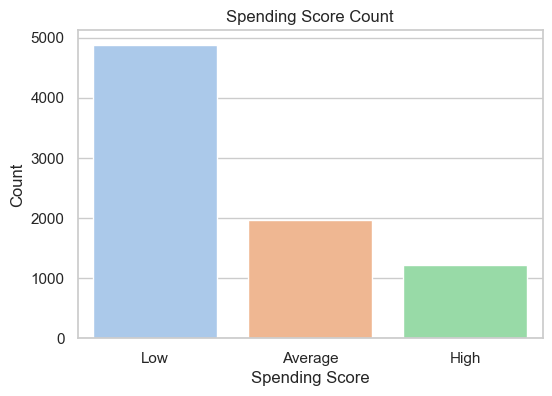

In [13]:
# 2. Spending Score distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Spending_Score', data=df, palette='pastel')
plt.title('Spending Score Count')
plt.xlabel('Spending Score')
plt.ylabel('Count')
plt.show()

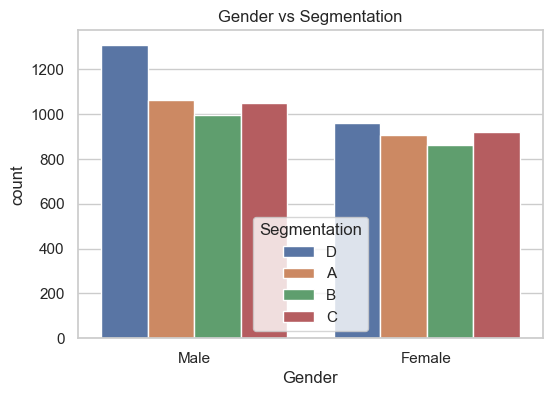

In [14]:
# 3. Gender vs Segmentation
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', hue='Segmentation', data=df)
plt.title('Gender vs Segmentation')
plt.show()

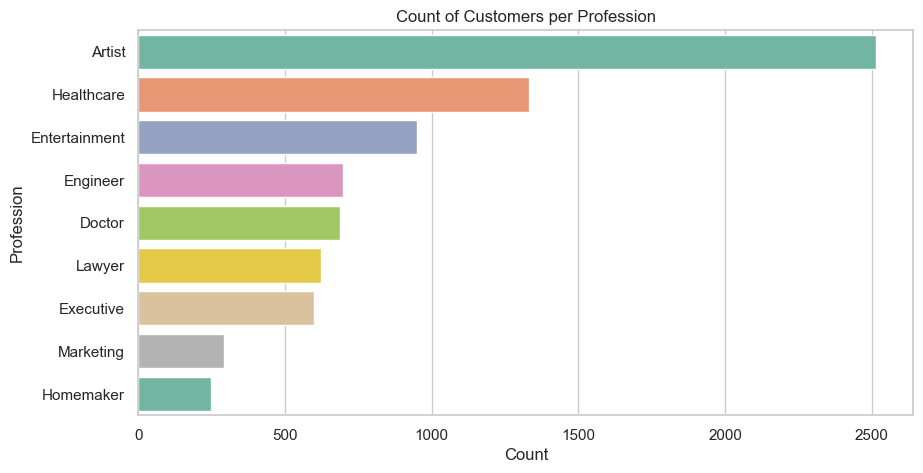

In [15]:
# 4. Profession count
plt.figure(figsize=(10, 5))
sns.countplot(y='Profession', data=df, order=df['Profession'].value_counts().index, palette='Set2')
plt.title('Count of Customers per Profession')
plt.xlabel('Count')
plt.ylabel('Profession')
plt.show()

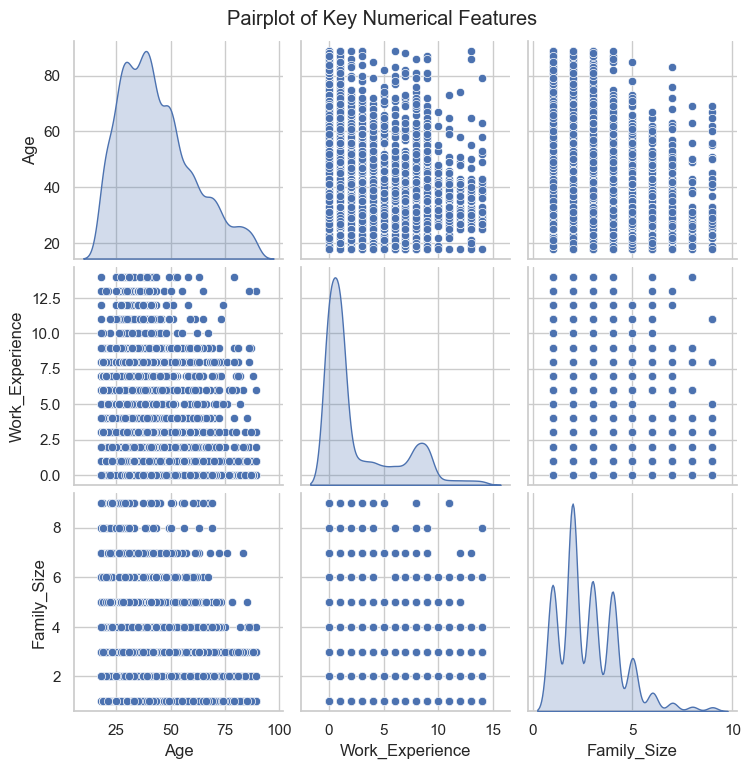

In [16]:
# 5. Pairplot of numerical features
sns.pairplot(df[['Age', 'Work_Experience', 'Family_Size']], diag_kind='kde')
plt.suptitle('Pairplot of Key Numerical Features', y=1.02)
plt.show()

Data Cleansing

In [17]:
# Dropping ID and Segmentation Column as not needed
df = df.drop(columns=['ID', 'Segmentation'])
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())


In [18]:
# One-hot encode
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
ohe = OneHotEncoder(sparse_output=False, drop='first')
enc = ohe.fit_transform(df[cat_cols])
enc_df = pd.DataFrame(enc,
                      columns=ohe.get_feature_names_out(cat_cols),
                      index=df.index)
proc_df = pd.concat([df.drop(columns=cat_cols), enc_df], axis=1)


In [19]:
# Standardize
scaler = StandardScaler()
scaled = scaler.fit_transform(proc_df)



In [20]:

# 4. Review
print("Missing values per column:")
print(df.isnull().sum())

print("\nUnique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Missing values per column:
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
dtype: int64

Unique values in each column:
Gender: 2
Ever_Married: 2
Age: 67
Graduated: 2
Profession: 9
Work_Experience: 15
Spending_Score: 3
Family_Size: 9
Var_1: 7


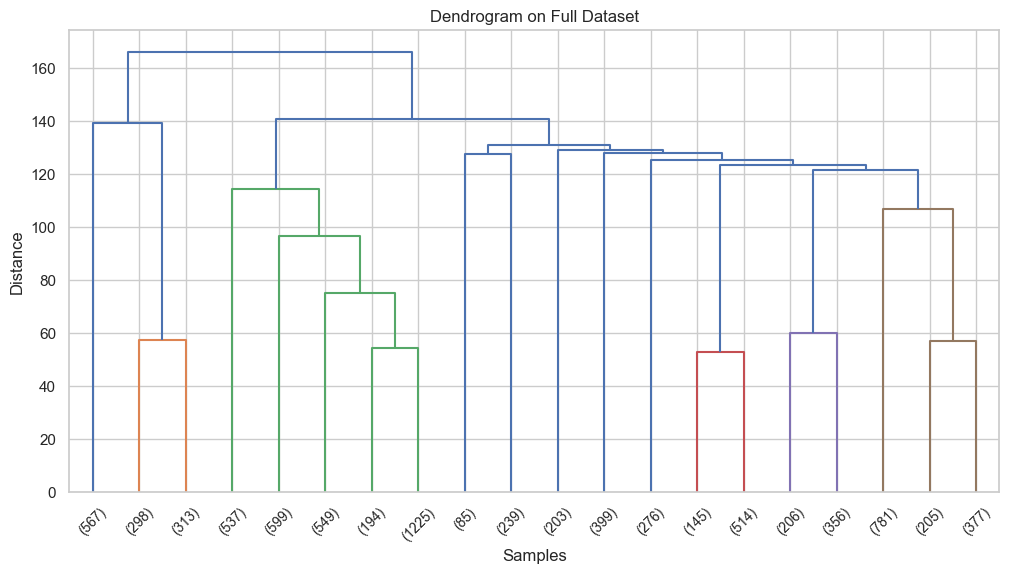

In [21]:

# Assuming 'scaled' is your full standardized dataset (after cleaning, encoding, etc.)
linked = linkage(scaled, method='ward')  # FULL data

# Optional: Visualize dendrogram (can be slow!)
plt.figure(figsize=(12, 6))
plt.title("Dendrogram on Full Dataset")
plt.xlabel("Samples")
plt.ylabel("Distance")
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45, leaf_font_size=10)
plt.show()


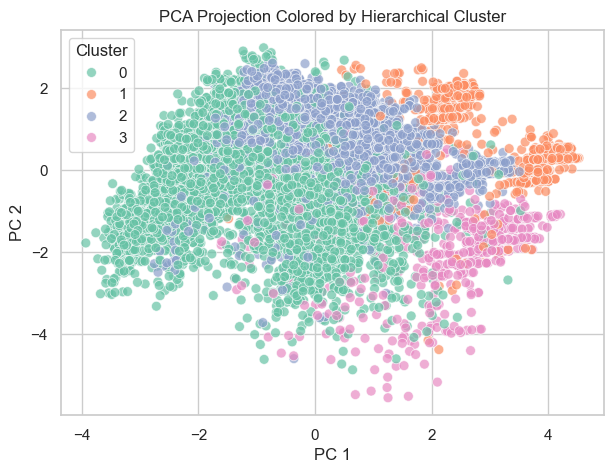

In [22]:
# --- 3. PCA + Cluster Assignment ---
pca = PCA(n_components=2)
pcs = pca.fit_transform(scaled)

hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = hc.fit_predict(scaled)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=pcs[:,0], y=pcs[:,1], hue=labels, palette='Set2', s=50, alpha=0.7)
plt.title('PCA Projection Colored by Hierarchical Cluster')
plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

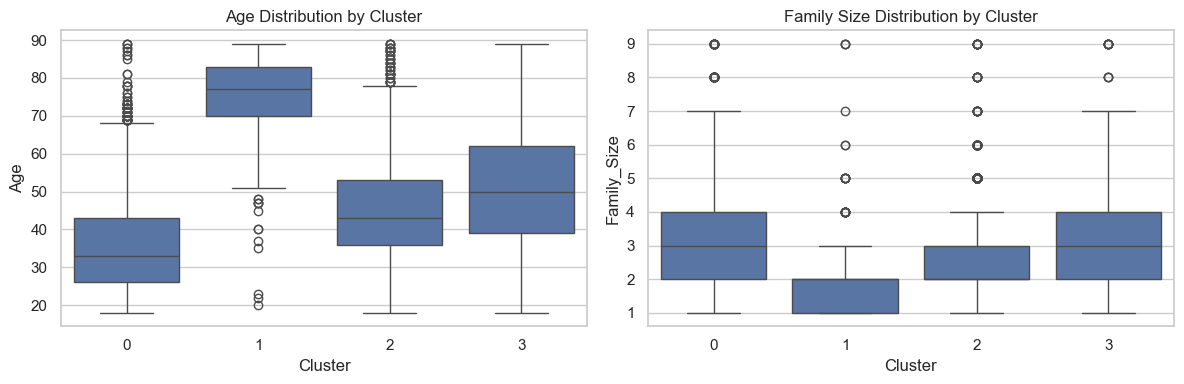

In [23]:
# --- 4. Feature Distributions by Cluster ---
df_profile = df.copy()
df_profile['Cluster'] = labels

# Example: Age and Family_Size
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x='Cluster', y='Age', data=df_profile, ax=axes[0])
axes[0].set_title('Age Distribution by Cluster')
sns.boxplot(x='Cluster', y='Family_Size', data=df_profile, ax=axes[1])
axes[1].set_title('Family Size Distribution by Cluster')
plt.tight_layout()
plt.show()

In [24]:
# 2. Fix inconsistent strings (strip spaces)
for col in df.select_dtypes(exclude='number').columns:
    df[col] = df[col].str.strip()


In [25]:
# Create a standardized DataFrame
scaled_df = pd.DataFrame(scaled, columns=proc_df.columns)

print("✅ Standardization Complete — Ready for Clustering")
print(scaled_df.describe().loc[['mean', 'std']])

✅ Standardization Complete — Ready for Clustering
               Age  Work_Experience   Family_Size   Gender_Male  \
mean  6.340986e-17    -4.139255e-17 -9.599549e-17  3.610839e-17   
std   1.000062e+00     1.000062e+00  1.000062e+00  1.000062e+00   

      Ever_Married_Yes  Graduated_Yes  Profession_Doctor  Profession_Engineer  \
mean      1.937524e-17  -4.403463e-18      -3.831013e-17        -3.919082e-17   
std       1.000062e+00   1.000062e+00       1.000062e+00         1.000062e+00   

      Profession_Entertainment  Profession_Executive  ...  Profession_Lawyer  \
mean             -2.906285e-17         -2.642078e-18  ...      -4.403463e-17   
std               1.000062e+00          1.000062e+00  ...       1.000062e+00   

      Profession_Marketing  Spending_Score_High  Spending_Score_Low  \
mean         -1.585247e-17         1.056831e-17        9.071133e-17   
std           1.000062e+00         1.000062e+00        1.000062e+00   

       Var_1_Cat_2   Var_1_Cat_3   Var_1_Cat_4   

In [26]:
# Step 1: Select numeric columns to apply Z-score
numeric_cols = ['Age', 'Work_Experience', 'Family_Size']  # update if you renamed these

# Step 2: Compute Z-scores on original scaled DataFrame
z_scores = scaled_df[numeric_cols].apply(zscore)

# Step 3: Create mask for rows with all Z-scores < 3
mask = (np.abs(z_scores) < 3).all(axis=1)

# Step 4: Apply mask to keep non-outlier rows
clean_scaled_df = scaled_df[mask].reset_index(drop=True)

# Optional: Save the original indices for later use (e.g., for syncing test data or raw data)
valid_indices = scaled_df[mask].index


print(f"✅ Outlier removal complete. Removed {len(scaled_df) - len(clean_scaled_df)} rows.")
print(f"Remaining records: {len(clean_scaled_df)}")


✅ Outlier removal complete. Removed 183 rows.
Remaining records: 7885


In [27]:

hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
cluster_labels = hc.fit_predict(clean_scaled_df)
clustered_df = clean_scaled_df.copy()
clustered_df['Cluster'] = cluster_labels
clustered_df.to_csv("train_with_clusters.csv", index=False)
print("✅ Hierarchical Clustering completed and Decision Tree model trained.")

✅ Hierarchical Clustering completed and Decision Tree model trained.


In [28]:
# --- 1. Split data into train/test ---


X_train, X_test, y_train, y_test = train_test_split(
    clean_scaled_df, cluster_labels, test_size=0.2, random_state=42
)

# --- 2. Retrain Decision Tree ---
clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)
clf.fit(X_train, y_train)


# --- 3. Predict on hold-out set ---
y_pred = clf.predict(X_test)

# --- 4. Evaluate ---
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))



📊 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90       656
           1       1.00      0.89      0.94       108
           2       0.88      0.98      0.93       702
           3       0.98      1.00      0.99       111

    accuracy                           0.92      1577
   macro avg       0.95      0.93      0.94      1577
weighted avg       0.93      0.92      0.92      1577



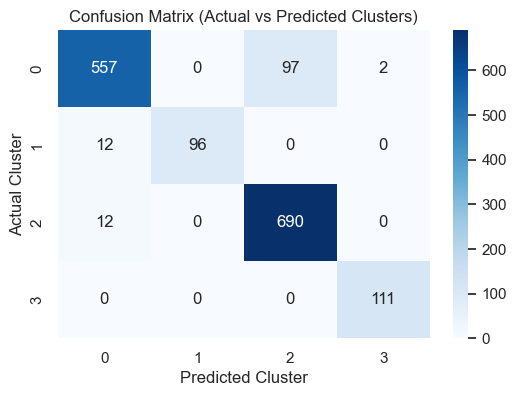

In [29]:
# --- 5. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(4), yticklabels=range(4))
plt.title('Confusion Matrix (Actual vs Predicted Clusters)')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Cluster')
plt.show()

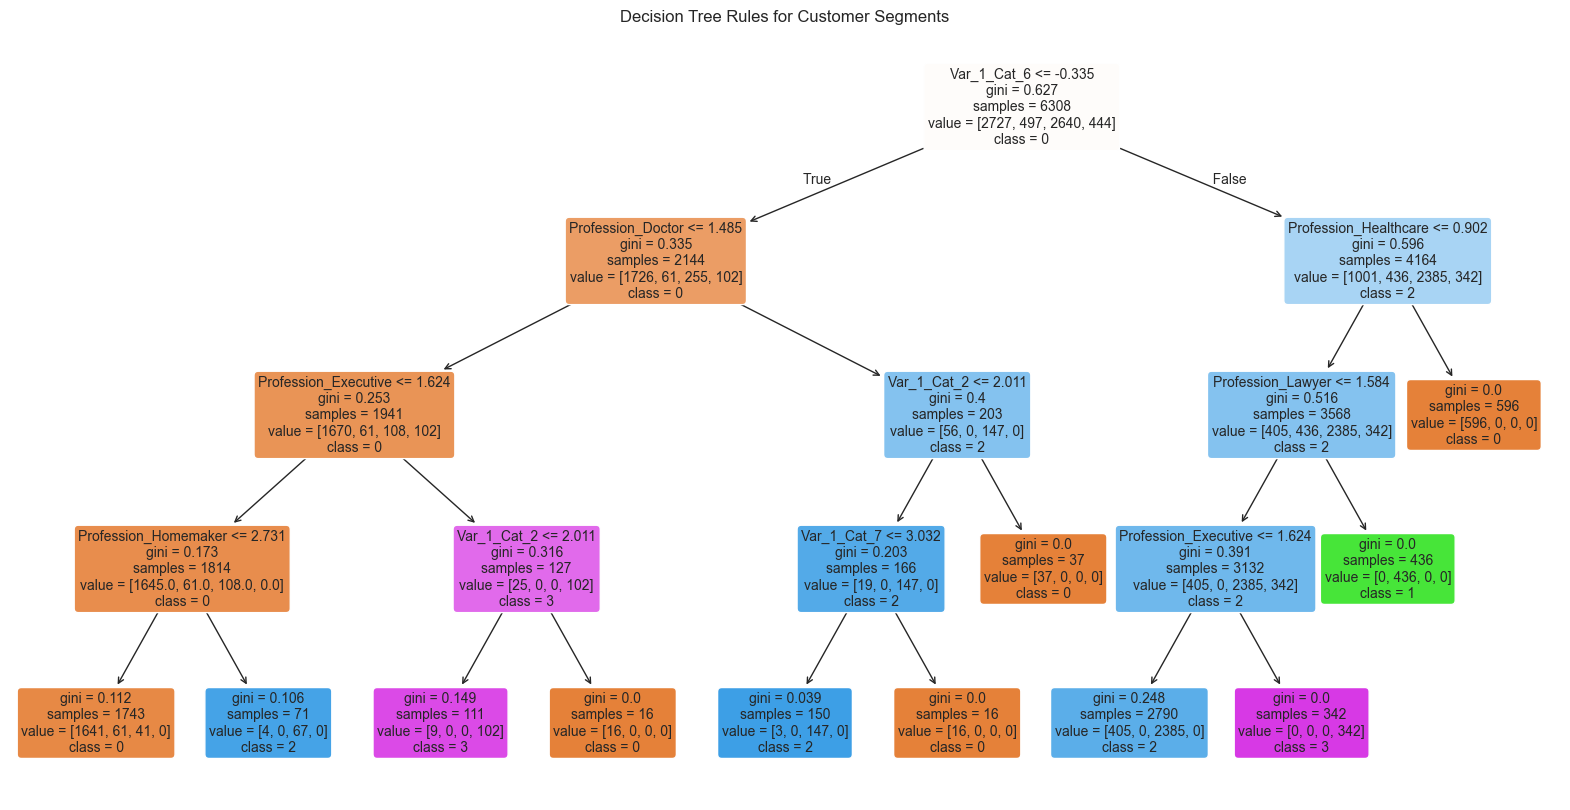

In [30]:
# --- 6. Visualize Decision Tree ---
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X_train.columns, class_names=[str(c) for c in clf.classes_], filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Rules for Customer Segments')
plt.show()


Cluster Distribution in Test

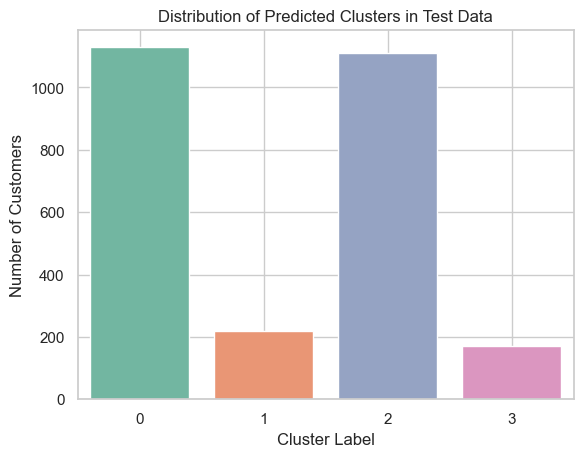

In [31]:
# Load predictions
df_pred = pd.read_csv('test_with_predicted_clusters.csv')

# Barplot of cluster distribution
sns.countplot(x='Predicted_Cluster', data=df_pred, palette='Set2')
plt.title('Distribution of Predicted Clusters in Test Data')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Customers')
plt.grid(True)
plt.show()

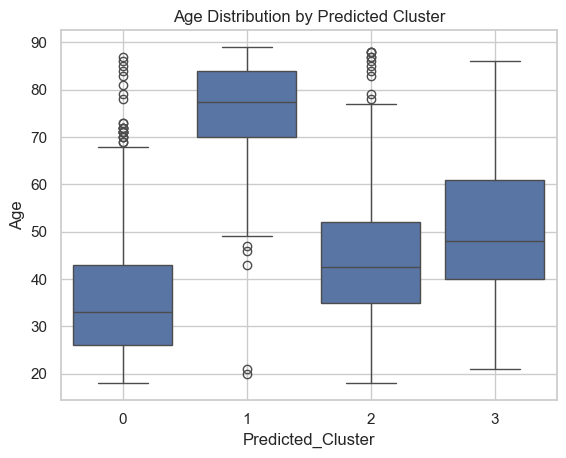

In [32]:
# Example: boxplot of Age by predicted cluster
sns.boxplot(x='Predicted_Cluster', y='Age', data=df_pred)
plt.title('Age Distribution by Predicted Cluster')
plt.grid(True)
plt.show()


In [33]:
# === Step 1: Load original test.csv ===
test_df = pd.read_csv('Test.csv')  # Use actual test file name
test_ids = test_df['ID']  # Save for final output
test_df_clean = test_df.drop(columns=['ID'])  # Work without ID column

# === Step 2: Clean and fill missing values (same as training) ===
for col in test_df_clean.columns:
    if not pd.api.types.is_numeric_dtype(test_df_clean[col]):
        test_df_clean[col] = test_df_clean[col].str.strip()
        test_df_clean[col] = test_df_clean[col].fillna(test_df_clean[col].mode()[0])
    else:
        test_df_clean[col] = test_df_clean[col].fillna(test_df_clean[col].median())

# === Step 3: Categorical columns used in training ===
cat_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']

# === Step 4: One-hot encode using trained encoder ===
encoded_test = ohe.transform(test_df_clean[cat_cols])
encoded_test_df = pd.DataFrame(encoded_test,
                               columns=ohe.get_feature_names_out(),
                               index=test_df_clean.index)

# === Step 5: Combine encoded + numeric columns ===
test_num_df = test_df_clean.drop(columns=cat_cols).reset_index(drop=True)
test_processed = pd.concat([test_num_df, encoded_test_df], axis=1)

# === Step 6: Scale using trained scaler ===
X_test_scaled = scaler.transform(test_processed)

# === Step 7: Predict cluster labels using trained Decision Tree ===
test_cluster_preds = clf.predict(X_test_scaled)

# === Step 8: Attach predictions to original test data ===
test_df['Predicted_Cluster'] = test_cluster_preds

# === Step 9: Save result ===
test_df.to_csv('test_with_predicted_clusters.csv', index=False)
print("✅ Model deployed successfully. Output saved to 'test_with_predicted_clusters.csv'")


✅ Model deployed successfully. Output saved to 'test_with_predicted_clusters.csv'


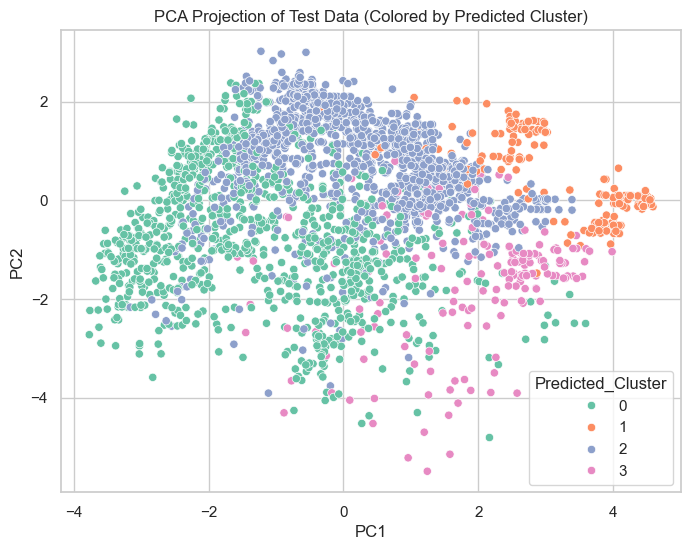

In [34]:
# Use the same standardized test data
pca = PCA(n_components=2)
test_pcs = pca.fit_transform(X_test_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(test_pcs, columns=['PC1', 'PC2'])
pca_df['Predicted_Cluster'] = test_cluster_preds

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Predicted_Cluster', palette='Set2')
plt.title('PCA Projection of Test Data (Colored by Predicted Cluster)')
plt.grid(True)
plt.show()


In [35]:
# Load test data with predictions
df_test = pd.read_csv('test_with_predicted_clusters.csv')

# Group by cluster and describe statistics
summary = df_test.groupby('Predicted_Cluster')[['Age', 'Work_Experience', 'Family_Size']].mean()
print("📊 Average Profile per Predicted Cluster:")
print(summary)


📊 Average Profile per Predicted Cluster:
                         Age  Work_Experience  Family_Size
Predicted_Cluster                                         
0                  36.193613         2.405765     3.294492
1                  76.215054         1.312500     1.906077
2                  43.774882         2.871391     2.510221
3                  50.907514         2.333333     3.481928


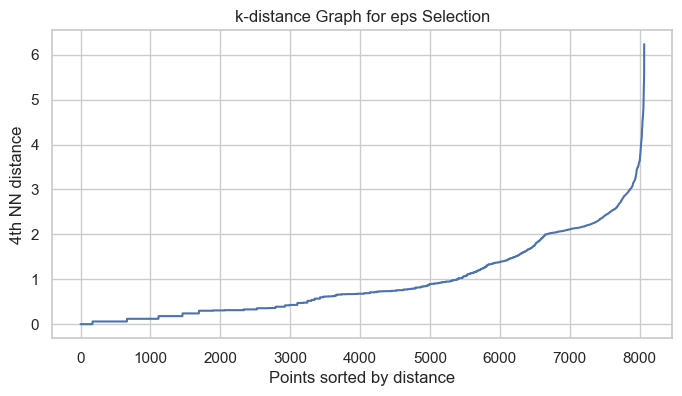

In [36]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# scaled_data from your preprocessing
nbrs = NearestNeighbors(n_neighbors=5).fit(scaled)
distances, _ = nbrs.kneighbors(scaled)
distances = np.sort(distances[:, 4])
plt.figure(figsize=(8,4))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel('4th NN distance')
plt.title('k-distance Graph for eps Selection')
plt.grid(True)
plt.show()


In [37]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering, DBSCAN

# Assume `scaled_data` and `pca_result` are from your previous cleansing & PCA steps

# — Hierarchical —
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
hc_labels = hc.fit_predict(scaled)

sil_hc = silhouette_score(scaled, hc_labels)
dbi_hc = davies_bouldin_score(scaled, hc_labels)

# — DBSCAN (tuned eps & min_samples) —
db = DBSCAN(eps=0.7, min_samples=5)   # adjust eps from your k-distance graph
db_labels = db.fit_predict(scaled)

# Exclude noise points for silhouette (silhouette_score cannot handle label -1)
mask = db_labels != -1
if mask.sum() > 1:
    sil_db = silhouette_score(scaled[mask], db_labels[mask])
    dbi_db = davies_bouldin_score(scaled[mask], db_labels[mask])
else:
    sil_db, dbi_db = None, None

print(f"Hierarchical → Silhouette: {sil_hc:.3f}, DB Index: {dbi_hc:.3f}")
print(f"DBSCAN      → Silhouette: {sil_db:.3f}, DB Index: {dbi_db:.3f}")
print(f"DBSCAN noise points: {(db_labels == -1).sum()} of {len(db_labels)}")


Hierarchical → Silhouette: 0.114, DB Index: 2.443
DBSCAN      → Silhouette: 0.460, DB Index: 0.656
DBSCAN noise points: 3299 of 8068


In [38]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

for eps in [0.8, 1.0, 1.2]:
    db = DBSCAN(eps=eps, min_samples=5).fit(scaled)
    labels = db.labels_
    n_noise = (labels == -1).sum()
    # silhouette only on non-noise
    mask = labels != -1
    sil = silhouette_score(scaled[mask], labels[mask]) if mask.sum()>1 else -1
    dbi = davies_bouldin_score(scaled[mask], labels[mask]) if mask.sum()>1 else np.inf
    print(f"eps={eps:.1f}: clusters={(len(set(labels))-(1 if -1 in labels else 0)):2d}, "
          f"noise={n_noise}, silhouette={sil:.3f}, DBI={dbi:.3f}")


eps=0.8: clusters=167, noise=2685, silhouette=0.440, DBI=0.729
eps=1.0: clusters=183, noise=2164, silhouette=0.420, DBI=0.813
eps=1.2: clusters=196, noise=1900, silhouette=0.409, DBI=0.855


In [39]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

eps = 0.8
for ms in [5, 10, 20, 50, 100]:
    db = DBSCAN(eps=eps, min_samples=ms).fit(scaled)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    
    # silhouette on non-noise
    mask = labels != -1
    if mask.sum() > 1 and n_clusters > 1:
        sil = silhouette_score(scaled[mask], labels[mask])
        dbi = davies_bouldin_score(scaled[mask], labels[mask])
    else:
        sil, dbi = np.nan, np.nan
    
    print(f"min_samples={ms:3d} → clusters={n_clusters:3d}, noise={n_noise:4d}, "
          f"silhouette={sil:.3f}, DBI={dbi:.3f}")


min_samples=  5 → clusters=167, noise=2685, silhouette=0.440, DBI=0.729
min_samples= 10 → clusters= 79, noise=3724, silhouette=0.468, DBI=0.727
min_samples= 20 → clusters= 38, noise=4792, silhouette=0.507, DBI=0.710
min_samples= 50 → clusters= 16, noise=6101, silhouette=0.592, DBI=0.590
min_samples=100 → clusters=  3, noise=7409, silhouette=0.625, DBI=0.601


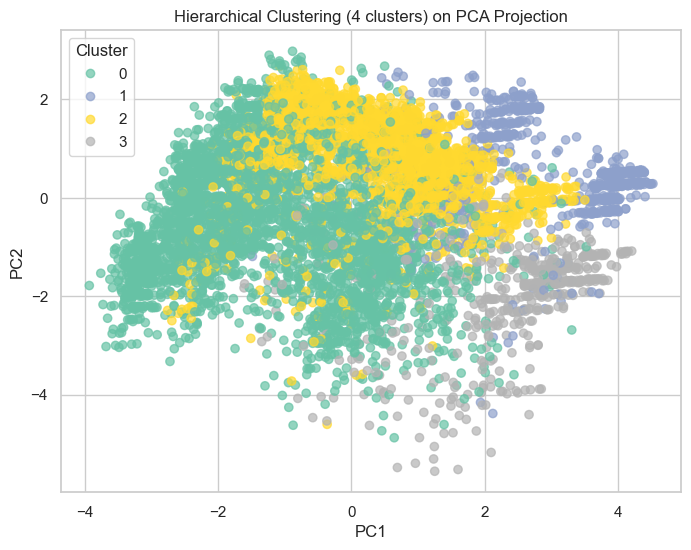

In [40]:
# 1. Load and clean data
df = pd.read_csv('train.csv')  # adjust filename
df = df.drop(columns=['ID', 'Segmentation'])
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# 2. Encode & scale
cat_cols = df.select_dtypes(exclude='number').columns
ohe = OneHotEncoder(sparse_output=False, drop='first')
enc = ohe.fit_transform(df[cat_cols])
enc_df = pd.DataFrame(enc, columns=ohe.get_feature_names_out(cat_cols), index=df.index)
num_df = df.drop(columns=cat_cols)
proc = pd.concat([num_df, enc_df], axis=1)

scaler = StandardScaler()
scaled = scaler.fit_transform(proc)


# 3. PCA to 2D
pca = PCA(n_components=2)
pc = pca.fit_transform(scaled)

# 4. Hierarchical clustering
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = hc.fit_predict(scaled)

# 5. Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(pc[:,0], pc[:,1], c=labels, cmap='Set2', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.title('Hierarchical Clustering (4 clusters) on PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

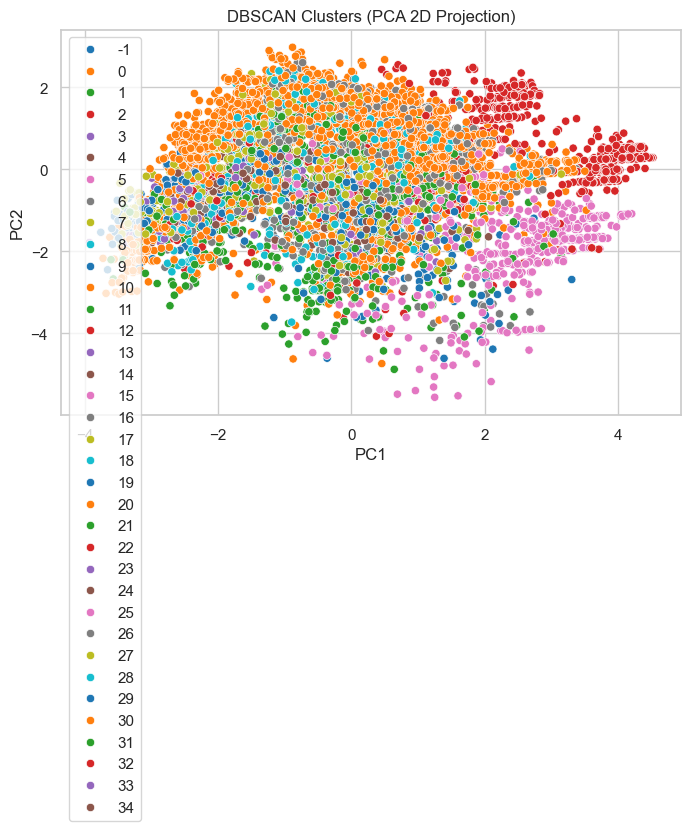

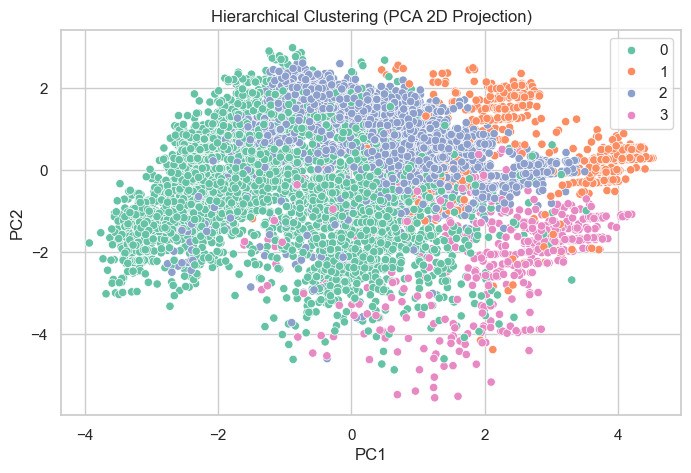

In [41]:
# ---------- DBSCAN ----------
dbscan = DBSCAN(eps=3, min_samples=5)  # You can tune eps/min_samples
dbscan_labels = dbscan.fit_predict(scaled)

# Plot DBSCAN clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=dbscan_labels, palette='tab10', legend='full')
plt.title('DBSCAN Clusters (PCA 2D Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# ---------- Hierarchical Clustering ----------
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')  # Tune clusters based on dendrogram or visual gap
hc_labels = hc.fit_predict(scaled)

# Plot Hierarchical clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=hc_labels, palette='Set2', legend='full')
plt.title('Hierarchical Clustering (PCA 2D Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [42]:
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv("Train.csv")
df.ffill(inplace=True)
df.drop(['ID', 'Segmentation'], axis=1, inplace=True)

# Encode Categorical Columns
le = LabelEncoder()
for col in df.select_dtypes(exclude='number').columns:
    df[col] = le.fit_transform(df[col])

X = df.copy()

In [43]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

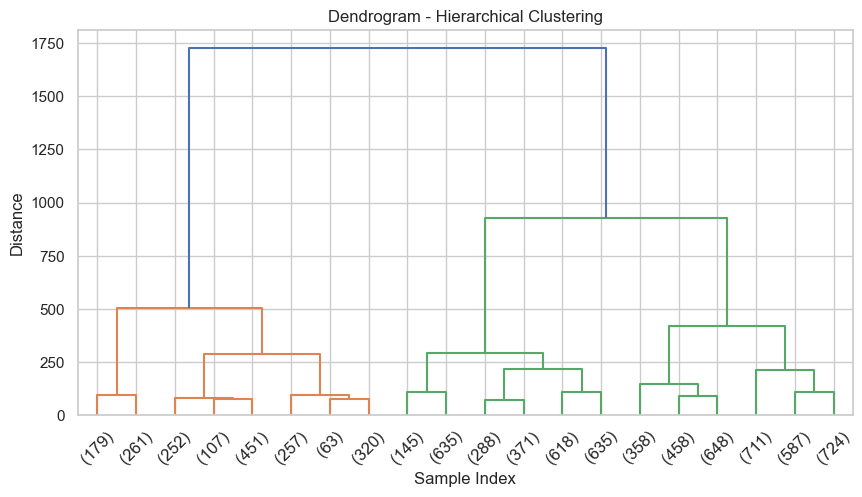

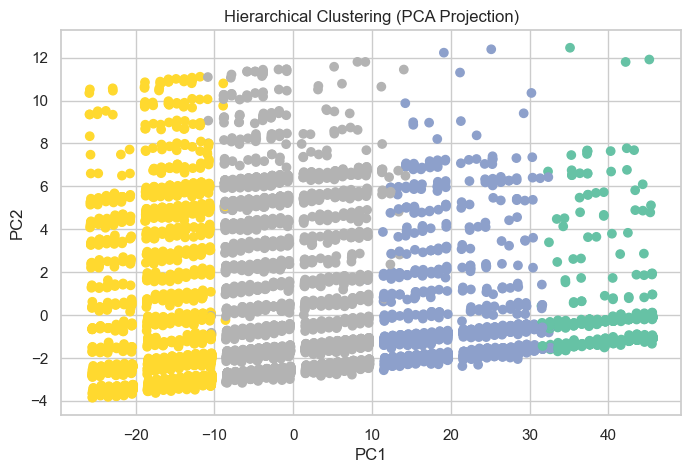

In [44]:
linked = linkage(X, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45, leaf_font_size=12)
plt.title('Dendrogram - Hierarchical Clustering')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# Create Clusters (Choose number based on dendrogram)
clusters_h = fcluster(linked, t=4, criterion='maxclust')

# Plot Hierarchical Clustering Result
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_h, cmap='Set2')
plt.title("Hierarchical Clustering (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
